### Import Library

In [ ]:
import os
import pandas as pd
import torch
from argparse import Namespace
from torch.utils.data import DataLoader
from MLPpatchLatent import Model

import sys
sys.path.insert(1, "/Users/yeojisu/Documents/House-Price-Index-Prediction")

from config.config_KR import *
from model.dfm_model import * 
from model.var_model import *
from model.kalman_filter import *
from utils.deep_learning import *
from utils.data_loader import *
from utils.visualization import *

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency information")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL

### Load Data

In [3]:
target_df = load_target_data(TARGET_PATH)
target_df_train = target_df[target_df.index < TEST_DATE]
target_df_test  = target_df[target_df.index >= TEST_DATE]

### Dynamic Factor Model (DFM)

In [4]:
dfm_results = run_dfm(target_df_train, target_df_test, REFERENCE_DATE, 5)
# train phase 
optimal_factors = dfm_results["optimal_factors"]
shared_component_final_train = dfm_results["shared_component_final_train"]
loadings     = dfm_results["loadings"]
scale_factor = dfm_results["scale_factor"]
offset       = dfm_results["offset"]

combined_array = dfm_results["combined_shared_component"]

factor_column_list = []
for i in range(optimal_factors):
    factor_column_list.append("factor"+str(i+1))

factor_df = pd.DataFrame(combined_array, columns=factor_column_list, index=target_df.index)


Optimization terminated successfully.
         Current function value: 18.458637
         Iterations: 17
         Function evaluations: 9882
DFM Training Time: 9.4880 sec
DFM Inference Time: 0.0070 sec


### Analysis

In [ ]:
feature_comp = load_feature_data(FEATURE_PATH, FEATURE_COLUMN, "2006-01-01")[:"2020-12-15"] # Train Data

In [ ]:
target_mean = target_df_train.mean().values
shared_val = (factor_df.values @ loadings.T) * scale_factor + target_mean + offset
shared_comp = pd.DataFrame(shared_val, index=None)
shared_comp.index = target_df.index
shared_comp.columns = target_df.columns
shared_comp = shared_comp.iloc[:-1][:"2020-12-15"] # Train Data

In [ ]:
target_df = target_df[:"2020-12-15"] # Train Data
trend_df = pd.DataFrame(index=target_df.index)

# STL for all HPI
for col in target_df.columns:
    series = target_df[col]
    stl = STL(series, period=12, robust=True)
    result = stl.fit()
    trend_df[col] = result.trend
# Extract Same Date 
aligned_stl = feature_comp.join(trend_df, how="inner")

# Calculate Corrlation with feature (X) and shared component (Y)
correlations_stl = aligned_stl.corr(method='pearson').loc[['call_rate', 'bond_3yr', 'loan_rate_avg', 'GDP_growth'], trend_df.columns]

# Extract Same Date 
aligned = feature_comp.join(shared_comp, how="inner")

# Calculate Corrlation with feature (X) and shared component (Y)
correlations = aligned.corr(method='pearson').loc[['call_rate', 'bond_3yr', 'loan_rate_avg', 'GDP_growth'], trend_df.columns]

-0.6944804017332997


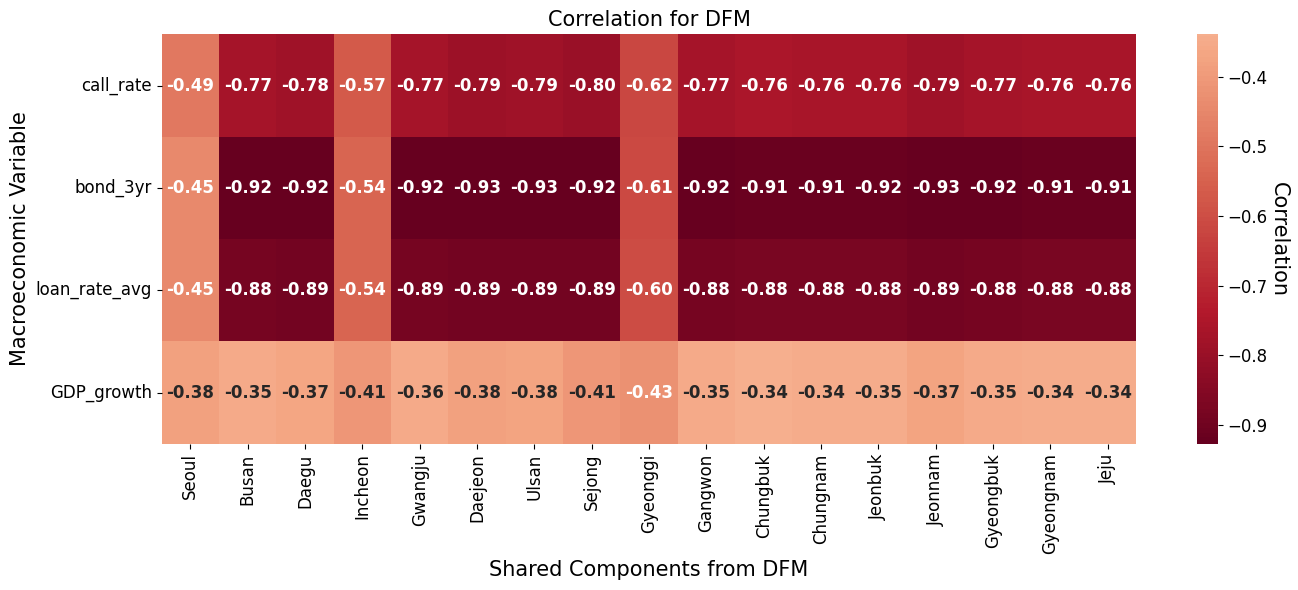

In [ ]:
plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    annot_kws={"size": 12, "weight": "bold"}  # 숫자 크기 키움
)

# 제목 및 컬러바 라벨
plt.title("Correlation for DFM", fontsize=15)
cbar = ax.collections[0].colorbar
cbar.set_label("Correlation", rotation=270, labelpad=15, fontsize=15)
cbar.ax.tick_params(labelsize=12)
new_yticklabels = [label.replace("_HPI", "") for label in correlations.columns]

plt.xlabel("Trends from DFM", fontsize=15)
plt.ylabel("Macroeconomic Variable", fontsize=15)
plt.yticks(rotation=0, fontsize=12)
ax.set_xticklabels(new_yticklabels, fontsize=12)
plt.tight_layout()
plt.savefig("DFM_corr.pdf", format="pdf")
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))
ax = sns.heatmap(
    correlations_stl,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    annot_kws={"size": 12, "weight": "bold"}  # 숫자 크기 키움
)

# 제목 및 컬러바 라벨
plt.title("Correlation for STL", fontsize=15)
cbar = ax.collections[0].colorbar
cbar.set_label("Correlation", rotation=270, labelpad=15, fontsize=15)
cbar.ax.tick_params(labelsize=12)
new_yticklabels = [label.replace("_HPI", "") for label in correlations_stl.columns]

plt.xlabel("Trends from STL", fontsize=15)
plt.ylabel("Macroeconomic Variable", fontsize=15)
plt.yticks(rotation=0, fontsize=12)
ax.set_xticklabels(new_yticklabels, fontsize=12)
plt.tight_layout()
plt.savefig("STL_corr.pdf", format="pdf")
plt.show()